## **3주차 과제 - NLP**

안녕하세요:) NLP 세션 과제를 맡은 24기 김승현입니다.

이번 과제는 이론 문제 1개와 실습 예제 1개로 구성되어 있습니다. **(GPU를 사용하세요!!)**

실습 파트에서는 고전적인 **TF-IDF 기반 모델**과 최신 **BERT(DistilBERT) 모델**을 직접 구현하며 성능 차이를 대조해 보는 데 중점을 두었습니다.

각 단계별 코드의 빈칸을 채워 실행해 보시길 바라며, 과제에 대해 궁금한 점이 생기시면 언제든 편하게 연락해 주세요!


# **Q1_이론문제**

**[문제]**

기존의 RNN은 문장을 순차적으로 처리하는 구조적 특성으로 인해 장기 의존성(Long-term dependency) 문제가 존재했다.

Transformer는 Self-Attention을 도입하여 이러한 한계를 극복하였다.

이때, **Self-Attention의 핵심 아이디어가 무엇인지 설명하고 RNN의 한계를 어떻게 해결하는지 서술하시오.**

Self-Attention의 핵심은 문장 내의 각 단어가 서로 어떤 관련이 있는지 스스로(Self) 점수를 매겨 계산하는 것이다.

1. 입력: 단어들이 들어오면 각 단어는 세 가지 벡터(Query, Key, Value)로 변환된다.
2. 과정: 특정 단어(Query)가 문장 내 모든 단어(Key)와의 유사도를 계산하여 '어떤 단어에 집중(Attention)할지' 결정한다.
3. 결과: 이 점수를 바탕으로 문맥이 충분히 반영된 새로운 단어 표현(Value의 가중치 합)을 만들어낸다.

예: "동생이 사과를 먹었다. 그것은 맛있다."라는 문장에서 Self-Attention은 '그것'이 앞의 '사과'와 가장 강력하게 연결되어 있다는 것을 수학적으로 찾아낸다.



---



RNN과 Transformer의 가장 큰 차이는 "정보를 전달하는 방식"에 있다.

RNN의 한계는 다음 두 가지로 요약할 수 있다.

1. 순차적 처리 (Sequential): 단어를 하나씩 순서대로 처리해야 한다. 문장이 길어질수록 앞부분의 정보가 뒤로 갈수록 희미해지는 장기 의존성(Long-term dependency) 문제가 발생한다. 이는 병렬적으로 한 번에 단어를 처리하는 방식과 구분되는 가장 큰 특징이다.

2. 기울기 소실 (Vanishing Gradient): 역전파 과정에서 가중치가 감소하기 때문에 멀리 떨어진 단어 사이의 관계를 학습하기가 아주 힘들다.


---


위에서 간단히 아이디어를 설명한 것처럼, Transformer는 병렬화를 통해 이를 해결한다.

1. Self-Attention은 문장의 길이에 상관없이 모든 단어 쌍을 직접 연결한다. 첫 번째 단어와 백 번째 단어 사이의 거리가 언제나 '1'이 되므로 거리나 순서에 따른 정보 소실 없이 직접적인 관계를 파악할 수 있다.

2. 순서대로 기다리지 않고 문장 전체를 한꺼번에 연산한다. (Parallelization)

3. 순차적 처리를 포기하는 대신, 단어의 위치 정보를 따로 더해주어 문장의 구조를 파악한다. 이를 Positional Encoding라고 한다.


# **Q2_실습문제**

NLP의 대표적인 예제인 영화 리뷰 데이터를 활용해 긍정/부정 감성 분석을 진행합니다.

텍스트 전처리부터 워드클라우드 시각화, 그리고 두 가지 모델(TF-IDF, BERT)의 구현까지 빈칸을 채우며 실습을 완료해 주세요.

참고) imdb 영화 리뷰 데이터
  - train: 학습용 데이터 25,000개
  - test: 검증용 데이터 25,000개
  - features: text(리뷰 내용), label(긍정/부정)


### Import Packages

In [ ]:
!pip -q install datasets transformers evaluate accelerate scikit-learn wordcloud matplotlib pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00


In [ ]:
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

### Data Load

In [ ]:
from datasets import load_dataset
ds = load_dataset("imdb")
ds["train"].to_pandas().head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [ ]:
# train data + test data -> df_all
label_names = ds["train"].features["label"].names
all_texts = list(ds["train"]["text"]) + list(ds["test"]["text"])
all_labels = list(ds["train"]["label"]) + list(ds["test"]["label"])

df_all = pd.DataFrame({"text": all_texts, "label": all_labels})
df_all["label_name"] = df_all["label"].map(lambda x: label_names[x])
df_all["label_name"].value_counts()

,count
label_name,
neg,25000
pos,25000


### Data Preprocessing


Text preprocessing 단계 중 정규화(Normalization) 중심으로 전처리를 수행합니다.

토큰화는 BERT 내부 토크나이저를 사용하므로, 전처리 단계에서는 별도로 수행하지 않습니다.

In [ ]:
def clean_text(t: str) -> str:
    # 1. HTML 태그 제거(웹 데이터에 섞인 <br/> 태그 등을 공백으로 치환)
    t = t.replace("<br />", " ")
    # 2. 정규화: 대소문자를 소문자로 통일
    t = t.lower()
    # 3. 정규화: 특수문자 제거
    t = re.sub(r"[^a-z\s]", " ", t)
    # 4. 불필요한 공백 제거
    t = re.sub(r"\s+", " ", t).strip()
    return t

# 전처리 함수 적용
df_all["clean"] = df_all["text"].map(clean_text)
df_all[["label_name", "text", "clean"]].head(5)

,label_name,text,clean
0,neg,I rented I AM CURIOUS-YELLOW from my video sto...,i rented i am curious yellow from my video sto...
1,neg,"""I Am Curious: Yellow"" is a risible and preten...",i am curious yellow is a risible and pretentio...
2,neg,If only to avoid making this type of film in t...,if only to avoid making this type of film in t...
3,neg,This film was probably inspired by Godard's Ma...,this film was probably inspired by godard s ma...
4,neg,"Oh, brother...after hearing about this ridicul...",oh brother after hearing about this ridiculous...


### WordCloud


긍정/부정 리뷰를 각각 샘플링하여 워드클라우드를 생성하면 자주 등장하는 단어를 시각적으로 비교할 수 있습니다.

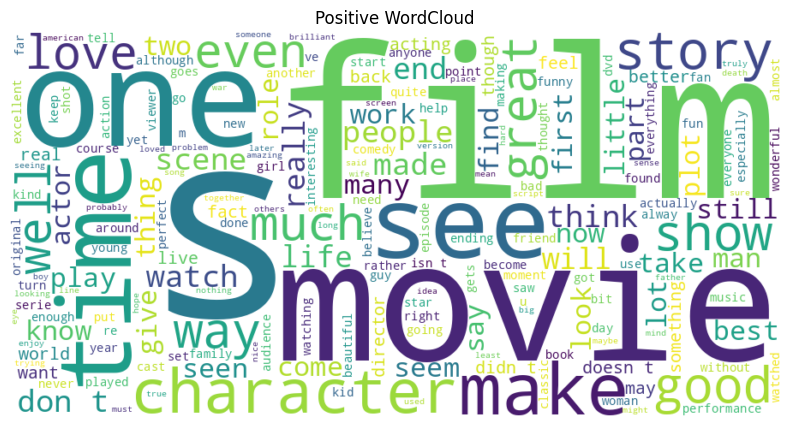

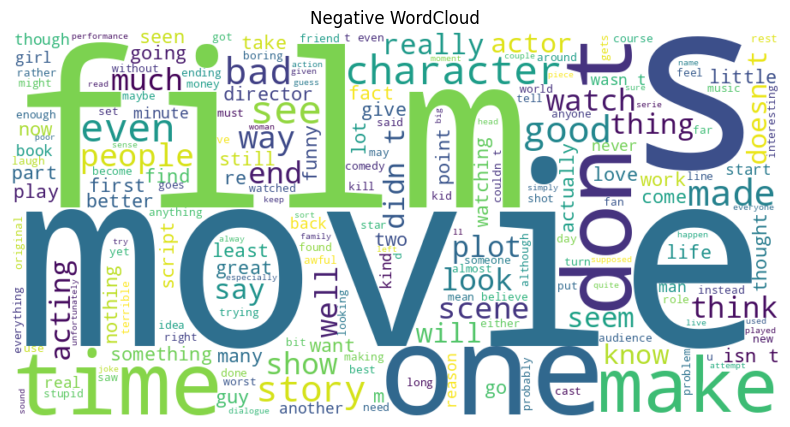

In [ ]:
SEED = 42

# 긍정/부정 리뷰 샘플링 후 하나의 문자열로 결합
pos_text = " ".join(df_all.loc[df_all["label_name"]=="pos", "clean"].sample(20000, random_state=SEED))
neg_text = " ".join(df_all.loc[df_all["label_name"]=="neg", "clean"].sample(20000, random_state=SEED))

# WordCloud 생성
wc_pos = WordCloud(width=900, height=450, background_color="white", max_words=200).generate(pos_text)
wc_neg = WordCloud(width=900, height=450, background_color="white", max_words=200).generate(neg_text)

# WordCloud 시각화
plt.figure(figsize=(14,5))
plt.imshow(wc_pos, interpolation="bilinear")
plt.axis("off")
plt.title("Positive WordCloud")
plt.show()

plt.figure(figsize=(14,5))
plt.imshow(wc_neg, interpolation="bilinear")
plt.axis("off")
plt.title("Negative WordCloud")
plt.show()

## **Model(1): TF-IDF + Logistic Regression**


첫번째 모델로는 딥러닝이 등장하기 전부터 자연어 처리 분야에서 널리 쓰여온 전통적인 머신러닝 방식을 실습합니다.

단어의 출현 빈도를 수치화하는 TF-IDF 기법과 선형 분류 알고리즘인 로지스틱 회귀를 결합하여 감성 분석 모델을 구현합니다.

In [ ]:
# 데이터 프레임 구성
train_df = pd.DataFrame(ds["train"])
test_df  = pd.DataFrame(ds["test"])

# Text Preprocessing 수행 (clean_text 함수 활용)
train_df["clean"] = train_df["text"].map(clean_text)
test_df["clean"]  = test_df["text"].map(clean_text)
X_train, y_train = train_df["clean"].values, train_df["label"].values
X_test,  y_test  = test_df["clean"].values,  test_df["label"].values

In [ ]:
# 처리 결과 확인
X_train[5]

'i would put this at the top of my list of films in the category of unwatchable trash there are films that are bad but the worst kind are the ones that are unwatchable but you are suppose to like them because they are supposed to be good for you the sex sequences so shocking in its day couldn t even arouse a rabbit the so called controversial politics is strictly high school sophomore amateur night marxism the film is self consciously arty in the worst sense of the term the photography is in a harsh grainy black and white some scenes are out of focus or taken from the wrong angle even the sound is bad and some people call this art'

In [ ]:
# TF-IDF 설정
tfidf = TfidfVectorizer(
    # 중요도 상위 30,000개의 단어만 사용
    max_features=30000,
    # 1-gram과 2-gram 모두 반영
    ngram_range=(1,2),
    # 최소 2개 이상의 출현 단어
    min_df=2
)

# 벡터화 적용
Xtr_tfidf = tfidf.fit_transform(X_train) # fit + transform
Xte_tfidf = tfidf.transform(X_test)
print("TF-IDF train shape:", Xtr_tfidf.shape)
print("TF-IDF test  shape:", Xte_tfidf.shape)
print("Vocab size:", len(tfidf.vocabulary_))

TF-IDF train shape: (25000, 30000)
TF-IDF test  shape: (25000, 30000)
Vocab size: 30000


In [ ]:
## 예시) 샘플 문서의 TF-IDF 상위 단어 확인
feature_names = np.array(tfidf.get_feature_names_out())

sample_idx = 14204              # 리뷰 인덱스 -> 숫자 바꿔가면서 확인해보기 !!
row = Xtr_tfidf[sample_idx]    # 해당 리뷰의 TF-IDF 벡터
topk = 15                      # 상위 15개 단어 확인

sorted_idx = np.argsort(row.data)[::-1][:topk]
top_features = row.indices[sorted_idx]
top_scores = row.data[sorted_idx]

print("샘플 원문(전처리 후):")
print(X_train[sample_idx][:400], "...\n")

print(f"Top {topk} TF-IDF features:") # 점수가 높을수록 그 단어는 이 리뷰에서는 자주 나오지만, 다른 리뷰들에서는 흔치 않은 변별력 있는 단어
for f, s in zip(feature_names[top_features], top_scores):
    print(f"{f:20s}  {s:.4f}")

샘플 원문(전처리 후):
the year old virgin is about andy stitzer a forty year old man who works in an electronic store and doesn t have much of a social life and is very awkward around women some of his co workers at the store invite him out one night and they discover that andy is still a virgin so they plan to help him lose his virginity one day in the store andy meets a woman named trish who gives him her phone numbe ...

Top 15 TF-IDF features:
andy                  0.2497
virgin                0.2189
old virgin            0.1968
good                  0.1791
year                  0.1777
the year              0.1758
year old              0.1507
and                   0.1466
awkward               0.1413
store                 0.1245
is sweet              0.1232
courage to            0.1178
the store             0.1173
courage               0.1030
works                 0.1021


In [ ]:
# 로지스틱 회귀모델 학습
lr = LogisticRegression(max_iter=2000, n_jobs=None)
lr.fit(Xtr_tfidf, y_train) # 어떤 단어가 긍정/부정에 기여하는지 가중치 설정

LogisticRegression(max_iter=2000)

In [ ]:
# 로지스틱 회귀모델 결과
pred_lr = lr.predict(Xte_tfidf)
print("\nClassification Report:\n", classification_report(y_test, pred_lr, target_names=label_names))


Classification Report:
               precision    recall  f1-score   support

         neg       0.90      0.89      0.90     12500
         pos       0.89      0.90      0.90     12500

    accuracy                           0.90     25000
   macro avg       0.90      0.90      0.90     25000
weighted avg       0.90      0.90      0.90     25000



In [ ]:
# Confusion Matrix
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_lr))
# TN / FP / FN / TP 순서

Confusion Matrix:
 [[11163  1337]
 [ 1261 11239]]


In [ ]:
## 추가) 회귀 계수 기반 감성 기여 단어 확인
coef = lr.coef_.ravel()
top_pos_idx = np.argsort(coef)[-20:][::-1]
top_neg_idx = np.argsort(coef)[:20]

print("긍정에 기여 큰 단어(상위 20):")
print(feature_names[top_pos_idx])

print("\n부정에 기여 큰 단어(상위 20):")
print(feature_names[top_neg_idx])

긍정에 기여 큰 단어(상위 20):
['great' 'excellent' 'wonderful' 'perfect' 'amazing' 'the best' 'best'
 'fun' 'today' 'love' 'loved' 'and' 'well' 'brilliant' 'favorite' 'superb'
 'enjoyed' 'beautiful' 'bit' 'highly']

부정에 기여 큰 단어(상위 20):
['bad' 'worst' 'awful' 'the worst' 'boring' 'poor' 'waste' 'terrible' 'no'
 'nothing' 'worse' 'dull' 'horrible' 'stupid' 'poorly' 'unfortunately'
 'annoying' 'script' 'ridiculous' 'even']


## **Model(2): BERT**

두번째로 딥러닝 기반의 사전학습 언어모델인 BERT를 활용하여 감성 분류를 수행합니다.

Self-Attention 기반의 Transformer 구조를 통해 문맥 정보를 양방향으로 반영하며 사전학습된 DistilBERT 모델을 파인튜닝하여 분류 성능을 향상시킵니다.

**아래 코드의 빈칸을 채워 모델을 완성한 후, 하이퍼파라미터를 조정하며 성능 변화를 비교해 보세요 !!**


In [ ]:
# 사전학습 DistilBERT(BERT의 경량화 버전) 모델 설정
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 배치 단위 토큰화
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        max_length=300,         # 최대 토큰 길이
        truncation=True,        # 최대 길이 초과 시 잘라내기
        padding="max_length"    # 최대 길이 기준 패딩
    )

# 토큰화 적용
ds_tok = ds.map(tokenize_batch, batched=True)
# trainer에서 원본 리뷰 컬럼 제거
ds_tok = ds_tok.remove_columns(["text"]) # 모델은 이제 숫자로 변환된 input_ids와 attention_mask만 보고 학습함
# label → labels 컬럼명 변경 (Trainer 호환)
ds_tok = ds_tok.rename_column("label", "labels")
# PyTorch 텐서 형식 변환
ds_tok.set_format("torch")

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [ ]:
SEED = 42

# DistilBERT 모델 로드
model_bert = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2) # 긍정/부정 2가지로 분류

# 평가 지표 로드
metric_acc = evaluate.load("accuracy")
metric_f1  = evaluate.load("f1")

# 평가 함수 정의
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": metric_acc.compute(predictions=preds, references=labels)["accuracy"],
        "f1": metric_f1.compute(predictions=preds, references=labels, average="binary")["f1"]
    }

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# 학습 하이퍼파라미터 설정 -> 파라미터 조절하기 !!
training_args = TrainingArguments(
    output_dir="./imdb_distilbert",  # 모델 저장 경로
    eval_strategy="steps",           # 평가 수행 기준 (epoch or steps)
    save_strategy="no",              # 체크포인트 저장 여부
    logging_strategy="steps",        # 로그 출력 기준 (epoch or steps)
    logging_steps=200,               # 로그 출력 간격 (step 단위)
    per_device_train_batch_size=32,  # 학습 배치 크기
    per_device_eval_batch_size=64,   # 평가 배치 크기
    num_train_epochs=1,              # 학습 epoch 수 (1에폭하는데 대략 12분 소요)
    learning_rate=2e-5,
    weight_decay=0.01,
    seed=SEED,
    report_to="none"
)

# Trainer 객체 생성
trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=ds_tok["train"],
    eval_dataset=ds_tok["test"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

# 모델 학습
trainer.train()

Step,Training Loss,Validation Loss,Accuracy,F1
200,0.349609,0.255733,0.896640,0.895138
400,0.265956,0.233130,0.906640,0.904329
600,0.249733,0.223077,0.909920,0.911589


TrainOutput(global_step=782, training_loss=0.2739434156881269, metrics={'train_runtime': 1325.0014, 'train_samples_per_second': 18.868, 'train_steps_per_second': 0.59, 'total_flos': 1940440410000000.0, 'train_loss': 0.2739434156881269, 'epoch': 1.0})

In [ ]:
# 모델 결과
eval_bert = trainer.evaluate()
eval_bert

{'eval_loss': 0.21626950800418854,
 'eval_accuracy': 0.91456,
 'eval_f1': 0.9143544506816359,
 'eval_runtime': 224.0732,
 'eval_samples_per_second': 111.571,
 'eval_steps_per_second': 1.745,
 'epoch': 1.0}

In [30]:
# Confusion Matrix
pred_out = trainer.predict(ds_tok["test"])
pred_bert = np.argmax(pred_out.predictions, axis=-1)
cm_bert = confusion_matrix(ds_tok["test"]["labels"], pred_bert)
print("BERT Confusion Matrix:\n", cm_bert)

BERT Confusion Matrix:
 [[11462  1038]
 [ 1098 11402]]


## **Results**

두 모델의 정확도를 비교하고 성능차이를 확인합니다.

In [33]:
# 모델별 정확도 계산
acc_lr = accuracy_score(y_test, pred_lr)
acc_bert = (pred_bert == np.array(ds["test"]["label"])).mean()
print(f"TF-IDF + LR Accuracy : {acc_lr:.4f}")
print(f"BERT Accuracy        : {acc_bert:.4f}")

TF-IDF + LR Accuracy : 0.8961
BERT Accuracy        : 0.9146


In [34]:
# 모델 예측 결과 비교용 데이터프레임 생성
compare_df = pd.DataFrame({
    "text": test_df["text"],
    "gold": test_df["label"].map(lambda x: label_names[x]),
    "lr": pd.Series(pred_lr).map(lambda x: label_names[x]),
    "bert": pd.Series(pred_bert).map(lambda x: label_names[x]),
})

compare_df["lr_correct"] = (compare_df["gold"] == compare_df["lr"])
compare_df["bert_correct"] = (compare_df["gold"] == compare_df["bert"])
compare_df["disagree"] = (compare_df["lr"] != compare_df["bert"])
compare_df.sample(10, random_state=124)   # random_state를 바꾸면서 결과 확인 해보세요 !!

,text,gold,lr,bert,lr_correct,bert_correct,disagree
23462,"I've just seen this movie, and it made me cry....",pos,pos,pos,True,True,False
20783,Do a title search on Randolph Scott and TRAIL ...,pos,pos,pos,True,True,False
11097,"Unbelievable. ""Philosophy"". ""Depth"". ""Genius""....",neg,neg,neg,True,True,False
9709,The DVD version released by Crash Cinema was v...,neg,neg,neg,True,True,False
21347,I accidentally bumped into this film on Cinema...,pos,pos,pos,True,True,False
22792,The Three Stooges has always been some of the ...,pos,pos,pos,True,True,False
3017,First the easy part: this movie is pretentious...,neg,neg,neg,True,True,False
20978,"There are many, many older movies that deserve...",pos,pos,pos,True,True,False
14989,I thought that the love letter was a pretty go...,pos,pos,pos,True,True,False
13743,I first saw this movie in the theater. I was 1...,pos,pos,pos,True,True,False


# 수고하셨습니다 :)